In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns   

In [3]:
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score



In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer


In [4]:
df = pd.read_csv("./Titanic-Dataset.csv",usecols=["Age","Survived","Fare"])
df.sample(3)

,Survived,Age,Fare
644,1,0.75,19.2583
448,1,5.00,19.2583
626,0,57.00,12.3500


In [5]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [13]:
df["Age"]=df["Age"].fillna(df["Age"].mean(),inplace=True)

C:\Users\shiva\AppData\Local\Temp\ipykernel_13220\214643200.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Age"]=df["Age"].fillna(df["Age"].mean(),inplace=True)


In [14]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [15]:
X = df.iloc[:,1:3]
y= df.iloc[:,0]
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.3,random_state=0)

C:\Users\shiva\AppData\Local\Temp\ipykernel_13220\3567177620.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train["Age"])


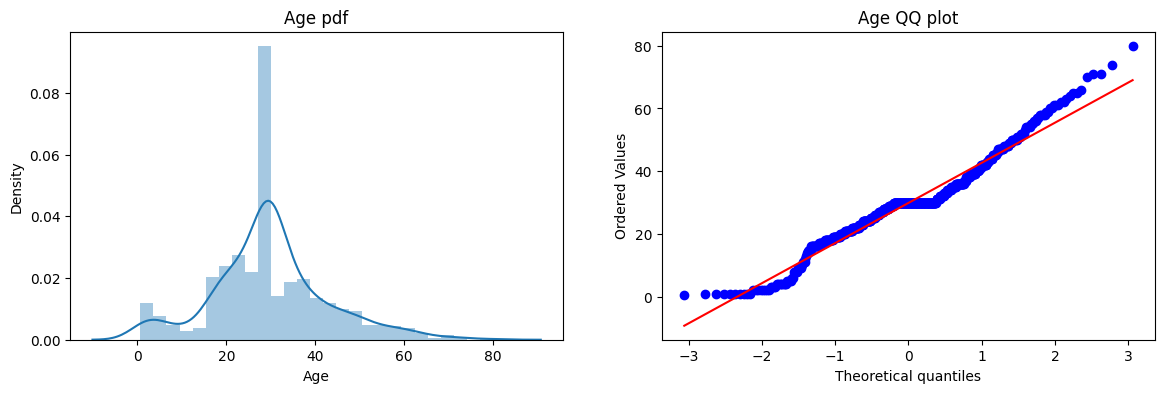

In [18]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train["Age"])
plt.title("Age pdf")
plt.subplot(122)
stats.probplot(X_train["Age"], dist="norm", plot=plt)
plt.title("Age QQ plot")

plt.show()

C:\Users\shiva\AppData\Local\Temp\ipykernel_13220\3579576823.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train["Fare"])


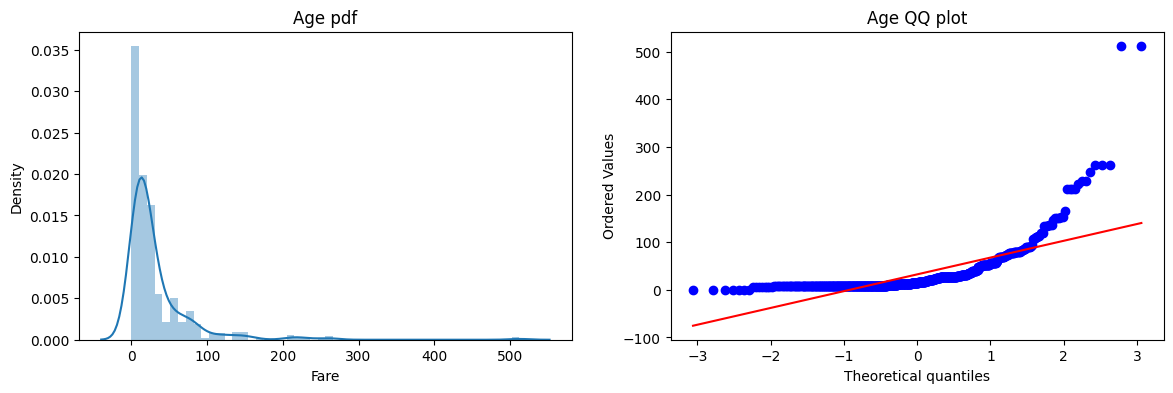

In [19]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train["Fare"])
plt.title("Age pdf")
plt.subplot(122)
stats.probplot(X_train["Fare"], dist="norm", plot=plt)
plt.title("Age QQ plot")

plt.show()

In [20]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()


In [22]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)
y_pred=clf.predict(X_test)
y_pred1 = clf2.predict(X_test)
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DTC",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6865671641791045
Accuracy DTC 0.6716417910447762


In [23]:
trf = FunctionTransformer(func=np.log1p)
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.fit_transform(X_test)



In [26]:
clf3 = LogisticRegression()
clf4 = DecisionTreeClassifier()

In [27]:
clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
y_pred=clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)
print("Accuracy LR2",accuracy_score(y_test,y_pred))
print("Accuracy DTC2",accuracy_score(y_test,y_pred1))

Accuracy LR2 0.7126865671641791
Accuracy DTC2 0.6791044776119403


In [31]:
X_transformed = trf.fit_transform(X)
clf = LogisticRegression()
clf2= DecisionTreeClassifier()
print("L2",np.mean(cross_val_score(clf,X_transformed,y,scoring="accuracy",cv=20)))
print("DTC2",np.mean(cross_val_score(clf2,X_transformed,y,scoring="accuracy",cv=20)))

L2 0.6771212121212122
DTC2 0.6575757575757575


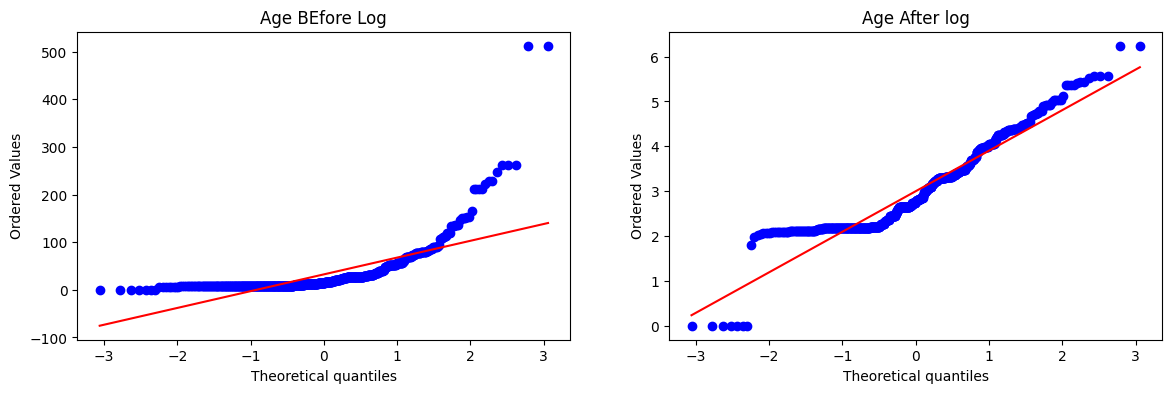

In [33]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train["Fare"], dist="norm", plot=plt)
plt.title("Age BEfore Log")

plt.subplot(122)
stats.probplot(X_train_transformed["Fare"],dist="norm",plot=plt)
plt.title("Age After log")
plt.show()

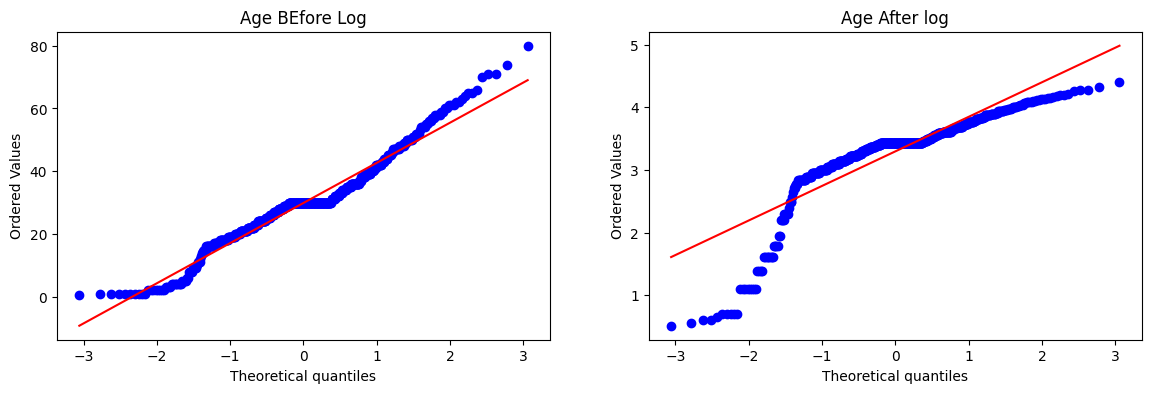

In [34]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train["Age"], dist="norm", plot=plt)
plt.title("Age BEfore Log")

plt.subplot(122)
stats.probplot(X_train_transformed["Age"],dist="norm",plot=plt)
plt.title("Age After log")
plt.show()